# AI-Powered Solar Energy Generation Forecasting
## Using Weather-Aware Machine Learning Models



## Introduction


In [6]:
import warnings
warnings.filterwarnings('ignore')

import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

import xgboost as xgb
import lightgbm as lgb

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import shap

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

PALETTE = [
    '#2196F3',
    '#FF9800',
    '#4CAF50',
    '#F44336',
    '#9C27B0',
    '#00BCD4'
]

print("All libraries loaded successfully!")
print(f"NumPy Version      : {np.__version__}")
print(f"Pandas Version     : {pd.__version__}")
print(f"XGBoost Version    : {xgb.__version__}")
print(f"LightGBM Version   : {lgb.__version__}")
print(f"TensorFlow Version : {tf.__version__}")

All libraries loaded successfully!
NumPy Version      : 2.3.1
Pandas Version     : 2.3.2
XGBoost Version    : 3.0.4
LightGBM Version   : 4.6.0
TensorFlow Version : 2.20.0



## Dataset Loading & Understanding


In [7]:
def make_synthetic_solar_data(n_days=90, freq='15T', seed=42):
    """
    Generate synthetic solar plant data with a structure similar
    to the Kaggle solar power generation dataset.
    """

    rng = np.random.default_rng(seed)

    date_index = pd.date_range(
        start='2020-06-01',
        periods=n_days * 96,
        freq=freq
    )

    df = pd.DataFrame({'DATE_TIME': date_index})

    hour = df['DATE_TIME'].dt.hour + df['DATE_TIME'].dt.minute / 60
    day_of_year = df['DATE_TIME'].dt.dayofyear

    solar_angle = np.clip(
        np.sin(np.pi * (hour - 6) / 12),
        0,
        1
    )

    seasonal_factor = (
        0.85 + 0.15 * np.sin(2 * np.pi * day_of_year / 365)
    )

    irradiation = (
        solar_angle *
        seasonal_factor *
        rng.uniform(0.7, 1.0, len(df))
    )

    irradiation = np.clip(irradiation, 0, 1)

    ambient_temp = (
        25 +
        10 * solar_angle +
        rng.normal(0, 1.5, len(df))
    )

    module_temp = (
        ambient_temp +
        12 * irradiation +
        rng.normal(0, 1, len(df))
    )

    capacity = 100

    dc_power = (
        capacity *
        irradiation *
        rng.uniform(0.88, 0.98, len(df))
    )

    ac_power = (
        dc_power *
        rng.uniform(0.96, 0.99, len(df))
    )

    df['PLANT_ID'] = 4135001
    df['SOURCE_KEY'] = 'bvBOhCH3iADSZry'
    df['DC_POWER'] = dc_power.round(3)
    df['AC_POWER'] = ac_power.round(3)

    df['DAILY_YIELD'] = (
        df.groupby(df['DATE_TIME'].dt.date)['AC_POWER']
        .cumsum()
        .values * 0.25
    )

    df['TOTAL_YIELD'] = df['DAILY_YIELD'].cumsum()

    df['AMBIENT_TEMPERATURE'] = ambient_temp.round(2)
    df['MODULE_TEMPERATURE'] = module_temp.round(2)
    df['IRRADIATION'] = irradiation.round(4)

    return df


GEN_PATH = r"C:\Users\prasa\Desktop\solar energy forecasting\Plant_1_Generation_Data.csv"
WEATHER_PATH = r"C:\Users\prasa\Desktop\solar energy forecasting\Plant_1_Weather_Sensor_Data.csv"

try:
    gen_df = pd.read_csv(
        GEN_PATH,
        parse_dates=['DATE_TIME']
    )

    weather_df = pd.read_csv(
        WEATHER_PATH,
        parse_dates=['DATE_TIME']
    )

    gen_df['DATE_TIME'] = pd.to_datetime(
        gen_df['DATE_TIME'],
        dayfirst=True
    )

    weather_df['DATE_TIME'] = pd.to_datetime(
        weather_df['DATE_TIME'],
        dayfirst=True
    )

    gen_agg = (
        gen_df.groupby('DATE_TIME', as_index=False)
        .agg({
            'DC_POWER': 'sum',
            'AC_POWER': 'sum',
            'DAILY_YIELD': 'sum',
            'TOTAL_YIELD': 'sum'
        })
    )

    df = pd.merge(
        gen_agg,
        weather_df,
        on='DATE_TIME',
        how='inner'
    )

    df.sort_values('DATE_TIME', inplace=True)
    df.reset_index(drop=True, inplace=True)

    print("Solar plant data loaded successfully.")

except FileNotFoundError:

    print("Dataset files not found. Using synthetic data instead.")

    df = make_synthetic_solar_data(n_days=90)

print(f"\nDataset Shape : {df.shape}")
print(f"Date Range    : {df['DATE_TIME'].min()} to {df['DATE_TIME'].max()}")
print(f"Columns       : {list(df.columns)}")

Solar plant data loaded successfully.

Dataset Shape : (3157, 10)
Date Range    : 2020-05-15 00:00:00 to 2020-06-17 23:45:00
Columns       : ['DATE_TIME', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']


In [8]:
print("First 5 rows:")
df.head()

First 5 rows:


,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,0.0,0.0,0.0,143581676.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,0.0,0.0,0.0,143581676.0,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,0.0,0.0,0.0,143581676.0,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,0.0,0.0,0.0,143581676.0,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,0.0,0.0,0.0,150761642.0,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [9]:
print("Last 5 rows:")
df.tail()

Last 5 rows:


,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
3152,2020-06-17 22:45:00,0.0,0.0,129571.000000,156142755.0,4135001,HmiyD2TTLFNqkNe,22.150570,21.480377,0.0
3153,2020-06-17 23:00:00,0.0,0.0,129571.000000,156142755.0,4135001,HmiyD2TTLFNqkNe,22.129816,21.389024,0.0
3154,2020-06-17 23:15:00,0.0,0.0,129571.000000,156142755.0,4135001,HmiyD2TTLFNqkNe,22.008275,20.709211,0.0
3155,2020-06-17 23:30:00,0.0,0.0,129571.000000,156142755.0,4135001,HmiyD2TTLFNqkNe,21.969495,20.734963,0.0
3156,2020-06-17 23:45:00,0.0,0.0,127962.767857,156142755.0,4135001,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0


In [10]:
print("\n Data Types & Memory Usage")
print("="*45)
info_df = pd.DataFrame({
    'Column'   : df.columns,
    'Dtype'    : df.dtypes.values,
    'Non-Null' : df.notna().sum().values,
    'Null'     : df.isna().sum().values,
    '% Null'   : (df.isna().mean() * 100).round(2).values
})
print(info_df.to_string(index=False))


 Data Types & Memory Usage
             Column          Dtype  Non-Null  Null  % Null
          DATE_TIME datetime64[ns]      3157     0     0.0
           DC_POWER        float64      3157     0     0.0
           AC_POWER        float64      3157     0     0.0
        DAILY_YIELD        float64      3157     0     0.0
        TOTAL_YIELD        float64      3157     0     0.0
           PLANT_ID          int64      3157     0     0.0
         SOURCE_KEY         object      3157     0     0.0
AMBIENT_TEMPERATURE        float64      3157     0     0.0
 MODULE_TEMPERATURE        float64      3157     0     0.0
        IRRADIATION        float64      3157     0     0.0


### Missing Value Analysis

In [11]:
# Check for missing values

missing = df.isna().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print("No missing values found in the dataset.")
else:
    plt.figure(figsize=(8, 4))
    missing.sort_values(ascending=False).plot(kind='bar')

    plt.title("Missing Values in Each Column")
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    print("\nMissing Values:")
    print(missing)

No missing values found in the dataset.


### Statistical Summary

In [12]:
print("\n Descriptive Statistics — Numerical Columns")
print("="*70)
num_cols = ['DC_POWER','AC_POWER','DAILY_YIELD',
            'AMBIENT_TEMPERATURE','MODULE_TEMPERATURE','IRRADIATION']
num_cols = [c for c in num_cols if c in df.columns]
summary = df[num_cols].describe().T
summary['CV%'] = (summary['std'] / summary['mean'] * 100).round(1)
print(summary.round(3).to_string())


 Descriptive Statistics — Numerical Columns
                      count       mean        std     min     25%        50%         75%         max    CV%
DC_POWER             3157.0  68560.020  88055.844   0.000   0.000   8430.196  140409.893  298937.786  128.4
AC_POWER             3157.0   6704.831   8604.218   0.000   0.000    814.880   13752.112   29150.212  128.3
DAILY_YIELD          3157.0  71798.458  65979.014   0.000  90.732  66068.000  129444.625  193770.000   91.9
AMBIENT_TEMPERATURE  3157.0     25.560      3.351  20.399  22.740     24.680      27.941      35.252   13.1
MODULE_TEMPERATURE   3157.0     31.175     12.273  18.140  21.130     24.802      41.449      65.546   39.4
IRRADIATION          3157.0      0.230      0.301   0.000   0.000      0.028       0.452       1.222  131.0



## Data Preprocessing


In [13]:
# Remove duplicate records

before = len(df)
df.drop_duplicates(subset='DATE_TIME', keep='first', inplace=True)

print(f"Duplicate rows removed: {before - len(df)}")


# Sort data by timestamp

df.sort_values('DATE_TIME', inplace=True)
df.reset_index(drop=True, inplace=True)


# Fill missing values

df[num_cols] = df[num_cols].fillna(method='ffill').fillna(method='bfill')

print(f"Missing values after filling: {df[num_cols].isna().sum().sum()}")


# Replace negative values with 0

for col in ['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'IRRADIATION']:
    if col in df.columns:

        neg = (df[col] < 0).sum()

        df[col] = df[col].clip(lower=0)

        if neg:
            print(f"Clipped {neg} negative values in {col}")


# Handle outliers using IQR

def clip_iqr(series, factor=3.0):

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR

    clipped = series.clip(lower, upper)

    n_clipped = (series < lower).sum() + (series > upper).sum()

    return clipped, n_clipped


print("\nOutlier Treatment Using IQR:")

for col in num_cols:

    df[col], n = clip_iqr(df[col])

    print(f"{col:<30} : {n} values clipped")


print(f"\nClean dataset shape: {df.shape}")

Duplicate rows removed: 0
Missing values after filling: 0

Outlier Treatment Using IQR:
DC_POWER                       : 0 values clipped
AC_POWER                       : 0 values clipped
DAILY_YIELD                    : 0 values clipped
AMBIENT_TEMPERATURE            : 0 values clipped
MODULE_TEMPERATURE             : 0 values clipped
IRRADIATION                    : 0 values clipped

Clean dataset shape: (3157, 10)



## Exploratory Data Analysis (EDA)


###  Distribution of Key Variables — Histograms

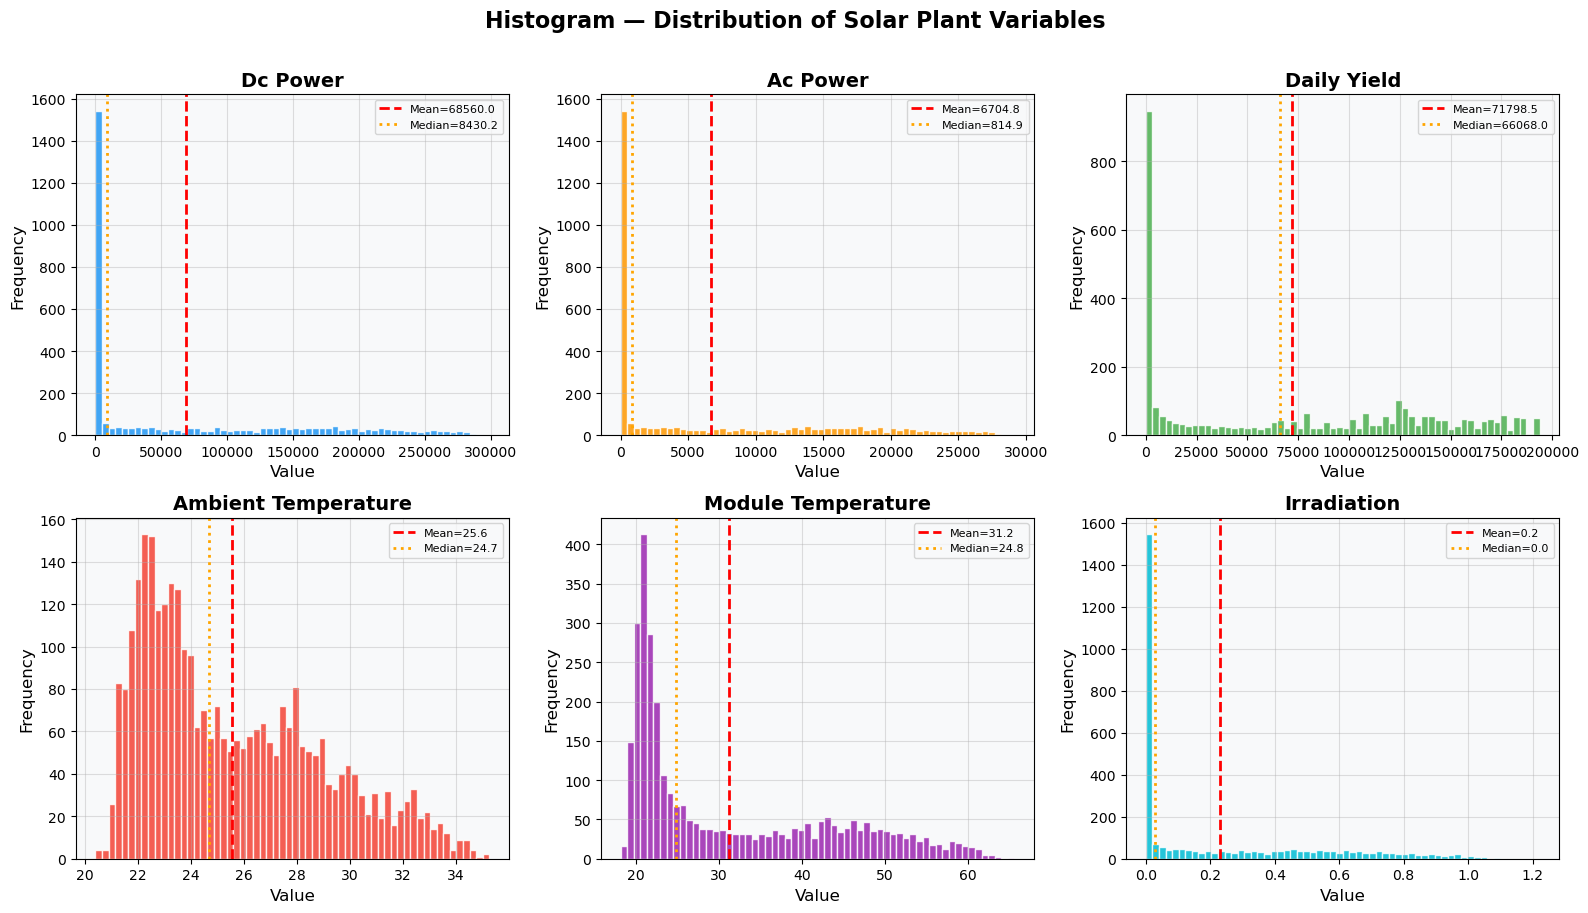


 Insight: AC_POWER and DC_POWER show a bimodal distribution — a large spike at zero
   (night-time / zero irradiation) and a right-skewed peak during daylight hours.
   Irradiation is heavily right-skewed, confirming most 15-min intervals have low sunlight.


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

plot_vars = num_cols[:6]
for i, col in enumerate(plot_vars):
    ax = axes[i]
    ax.hist(df[col], bins=60, color=PALETTE[i], edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(),   color='red',    lw=2, ls='--', label=f'Mean={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', lw=2, ls=':',  label=f'Median={df[col].median():.1f}')
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

plt.suptitle("Histogram — Distribution of Solar Plant Variables", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('hist_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Insight: AC_POWER and DC_POWER show a bimodal distribution — a large spike at zero")
print("   (night-time / zero irradiation) and a right-skewed peak during daylight hours.")
print("   Irradiation is heavily right-skewed, confirming most 15-min intervals have low sunlight.")

### Spread & Outliers by Hour of Day

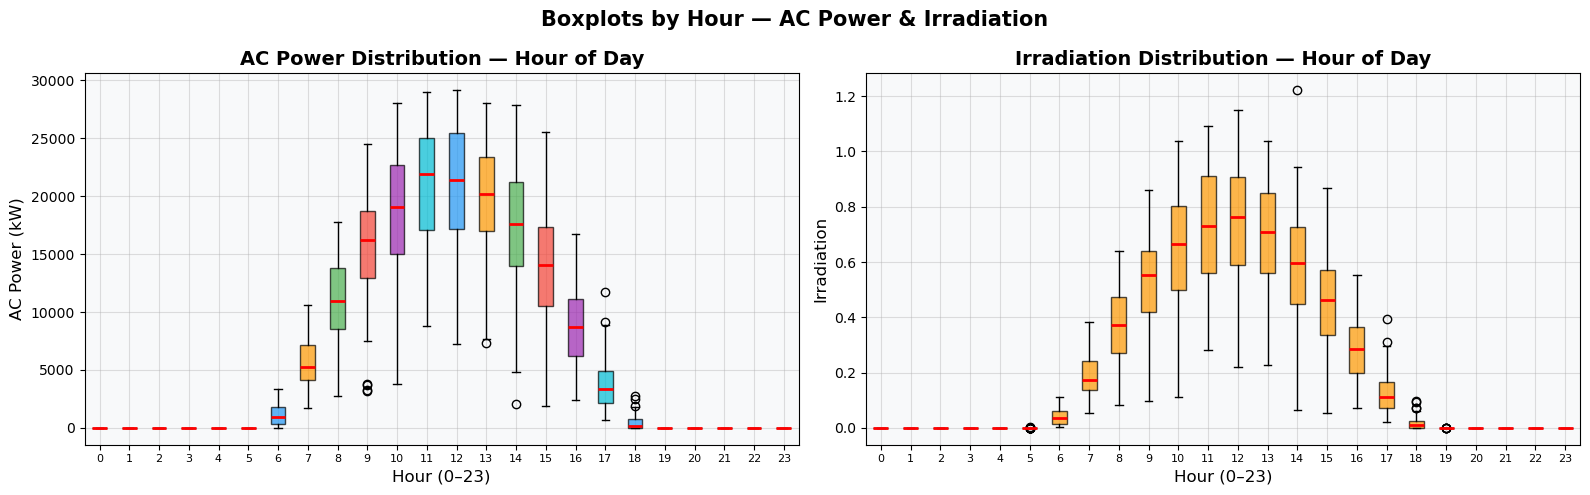


 Insight: Peak generation occurs 10 AM–2 PM (hours 10–14), matching solar noon.
   The wide interquartile range between 9–15 h reflects day-to-day weather variability.
   Zero spread at night confirms the quality of our outlier clipping — no ghost readings.


In [15]:
df['HOUR'] = df['DATE_TIME'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# AC Power by hour
hourly_ac = df.groupby('HOUR')['AC_POWER'].apply(list)
bp1 = axes[0].boxplot([hourly_ac[h] for h in range(24)],
                       patch_artist=True,
                       medianprops=dict(color='red', lw=2))
for patch, color in zip(bp1['boxes'], [PALETTE[i % len(PALETTE)] for i in range(24)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title("AC Power Distribution — Hour of Day", fontweight='bold')
axes[0].set_xlabel("Hour (0–23)")
axes[0].set_ylabel("AC Power (kW)")
axes[0].set_xticks(range(1, 25))
axes[0].set_xticklabels(range(24), fontsize=8)

# Irradiation by hour
hourly_irr = df.groupby('HOUR')['IRRADIATION'].apply(list)
bp2 = axes[1].boxplot([hourly_irr[h] for h in range(24)],
                       patch_artist=True,
                       medianprops=dict(color='red', lw=2))
for patch in bp2['boxes']:
    patch.set_facecolor('#FF9800')
    patch.set_alpha(0.7)
axes[1].set_title("Irradiation Distribution — Hour of Day", fontweight='bold')
axes[1].set_xlabel("Hour (0–23)")
axes[1].set_ylabel("Irradiation")
axes[1].set_xticks(range(1, 25))
axes[1].set_xticklabels(range(24), fontsize=8)

plt.suptitle("Boxplots by Hour — AC Power & Irradiation", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_hour.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Insight: Peak generation occurs 10 AM–2 PM (hours 10–14), matching solar noon.")
print("   The wide interquartile range between 9–15 h reflects day-to-day weather variability.")
print("   Zero spread at night confirms the quality of our outlier clipping — no ghost readings.")

### Correlation Heatmap

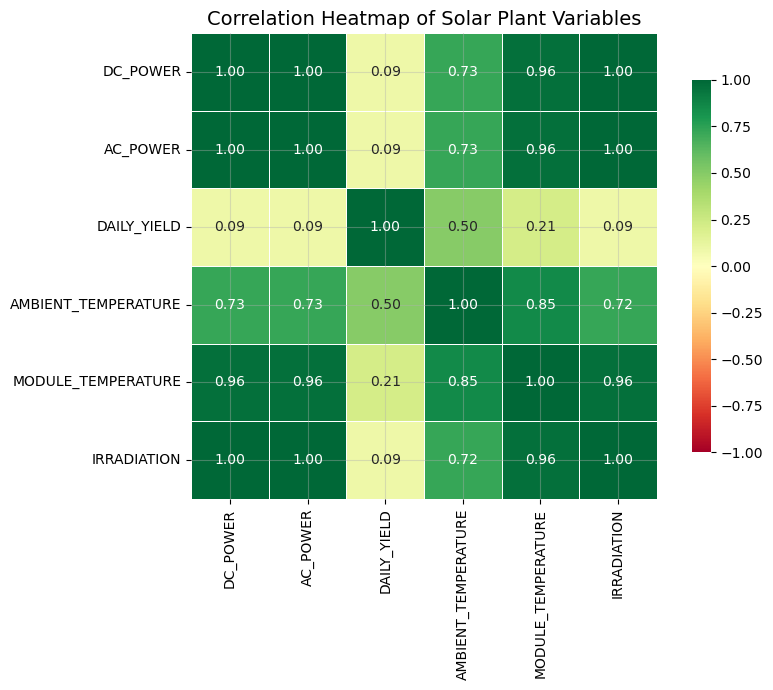


Correlation with AC_POWER:
DC_POWER                       1.000
IRRADIATION                    0.996
MODULE_TEMPERATURE             0.961
AMBIENT_TEMPERATURE            0.726
DAILY_YIELD                    0.092


In [16]:
corr_cols = [c for c in num_cols if c in df.columns]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))

mask = np.triu(
    np.ones_like(corr_matrix, dtype=bool),
    k=1
)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='RdYlGn',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)

ax.set_title("Correlation Heatmap of Solar Plant Variables")

plt.tight_layout()

plt.savefig(
    'correlation_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# Correlation with AC_POWER

if 'AC_POWER' in corr_matrix.columns:

    top_corr = (
        corr_matrix['AC_POWER']
        .drop('AC_POWER')
        .sort_values(key=abs, ascending=False)
    )

    print("\nCorrelation with AC_POWER:")

    for feature, value in top_corr.items():
        print(f"{feature:<30} {value:.3f}")

### Time-Series Plot — 7-Day Rolling View

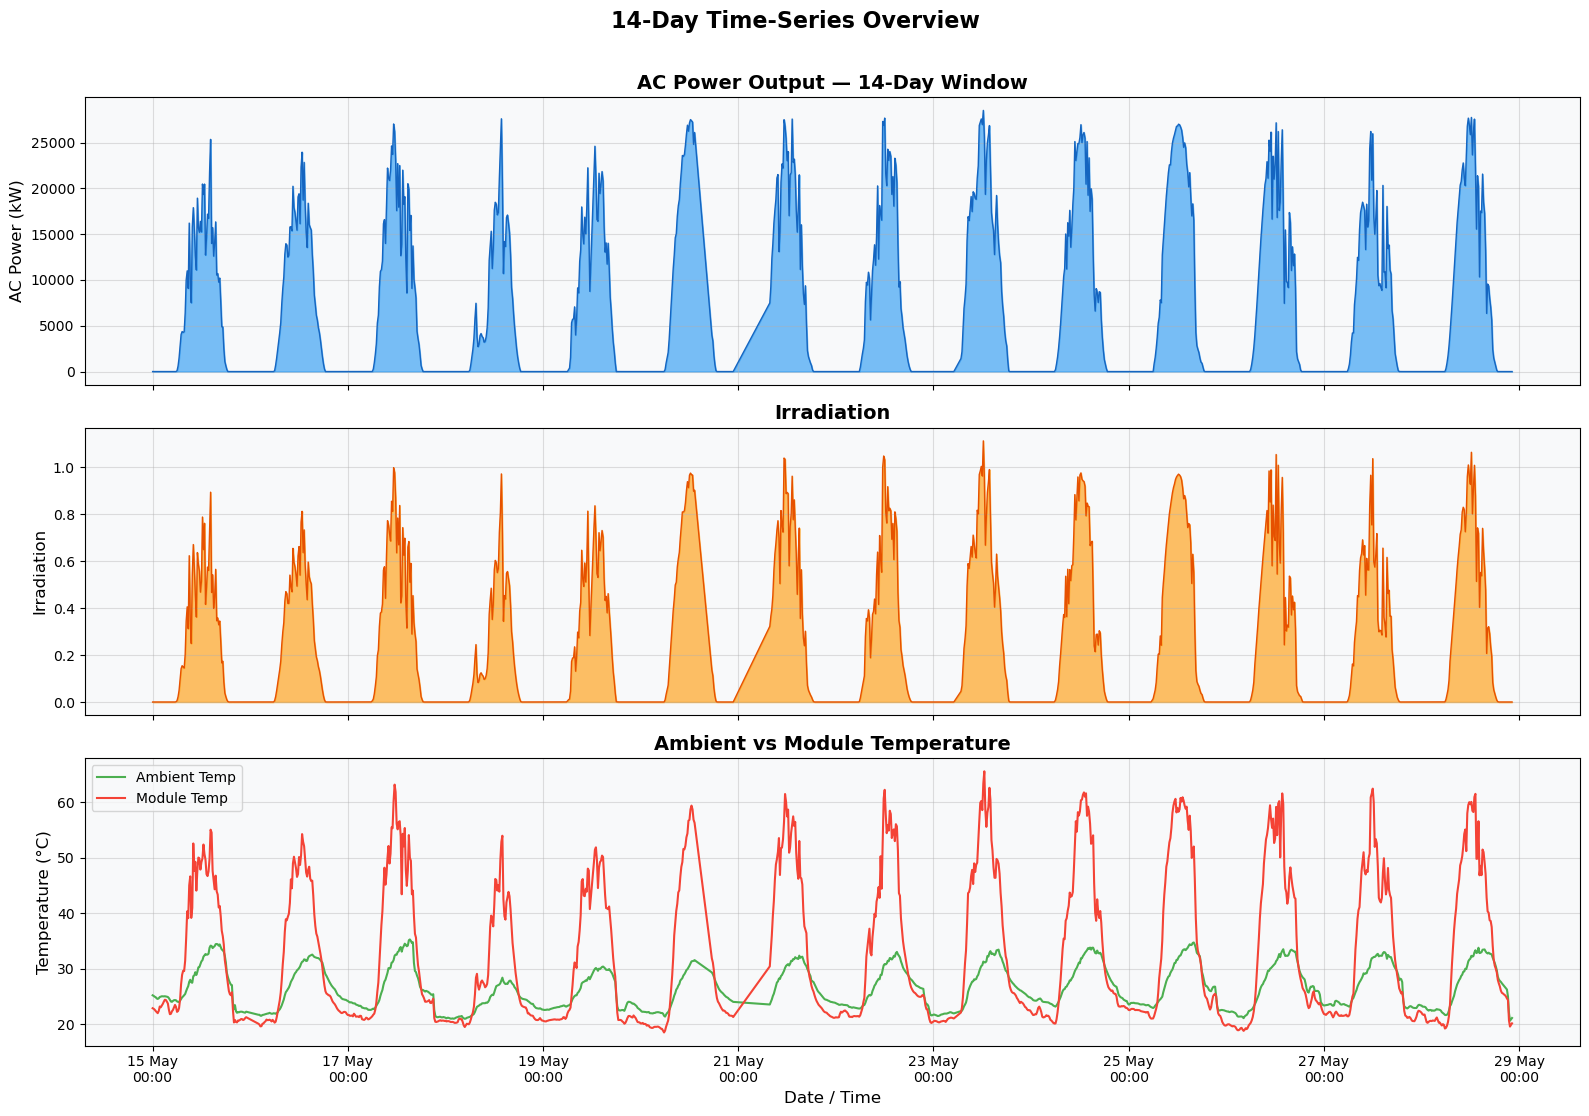


 Insight: The daily generation cycle is clearly visible with clean peaks each day.
   Module temperature consistently runs ~15–20°C above ambient during peak generation,
   which can actually reduce panel efficiency — a nuance our lag features will capture.


In [17]:
# Pick a 2-week window for readability
sample_start = df['DATE_TIME'].min()
sample_end   = sample_start + pd.Timedelta(days=14)
ts_df = df[(df['DATE_TIME'] >= sample_start) & (df['DATE_TIME'] <= sample_end)].copy()

fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)

axes[0].fill_between(ts_df['DATE_TIME'], ts_df['AC_POWER'], alpha=0.6, color='#2196F3')
axes[0].plot(ts_df['DATE_TIME'], ts_df['AC_POWER'], color='#1565C0', lw=1)
axes[0].set_ylabel("AC Power (kW)")
axes[0].set_title("AC Power Output — 14-Day Window", fontweight='bold')

axes[1].fill_between(ts_df['DATE_TIME'], ts_df['IRRADIATION'], alpha=0.6, color='#FF9800')
axes[1].plot(ts_df['DATE_TIME'], ts_df['IRRADIATION'], color='#E65100', lw=1)
axes[1].set_ylabel("Irradiation")
axes[1].set_title("Irradiation", fontweight='bold')

axes[2].plot(ts_df['DATE_TIME'], ts_df['AMBIENT_TEMPERATURE'],  label='Ambient Temp',  color='#4CAF50', lw=1.5)
axes[2].plot(ts_df['DATE_TIME'], ts_df['MODULE_TEMPERATURE'],   label='Module Temp',   color='#F44336', lw=1.5)
axes[2].set_ylabel("Temperature (°C)")
axes[2].set_title("Ambient vs Module Temperature", fontweight='bold')
axes[2].legend()

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b\n%H:%M'))
plt.xlabel("Date / Time")
plt.suptitle("14-Day Time-Series Overview", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('timeseries_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Insight: The daily generation cycle is clearly visible with clean peaks each day.")
print("   Module temperature consistently runs ~15–20°C above ambient during peak generation,")
print("   which can actually reduce panel efficiency — a nuance our lag features will capture.")

### Power Generation vs Weather Variables — Scatter Plots

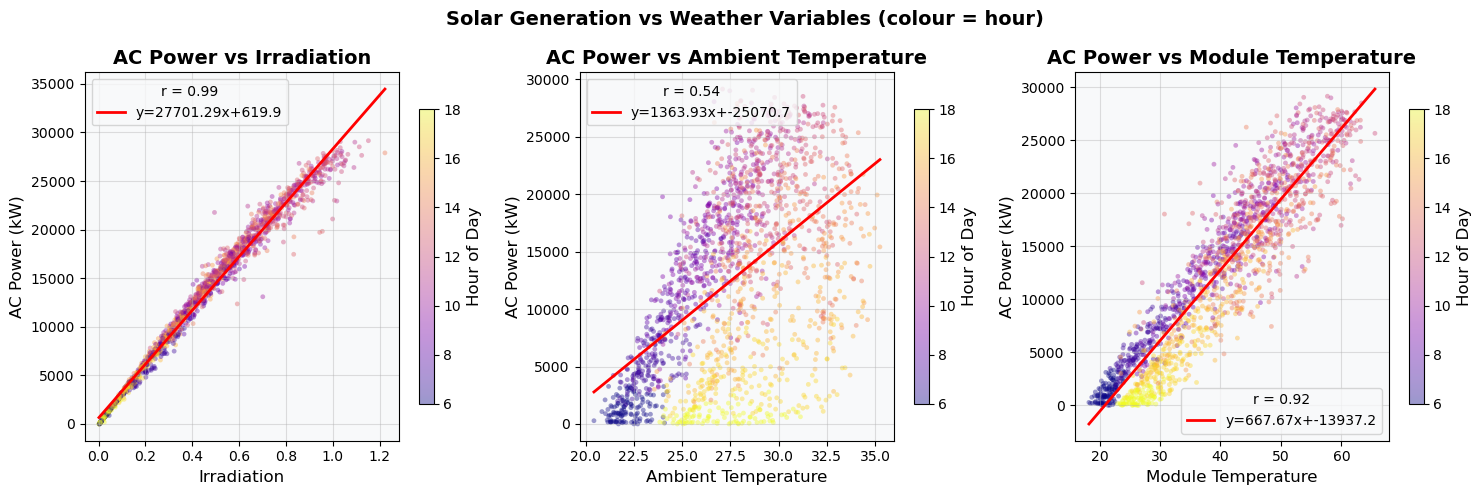


 Insight: Irradiation shows the strongest, most linear relationship with AC power.
   Temperature plots reveal a non-linear effect — extreme heat actually reduces efficiency,
   visible as a slight downward bend at very high module temperatures.


In [18]:
weather_feats = ['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']
weather_feats = [f for f in weather_feats if f in df.columns]

fig, axes = plt.subplots(1, len(weather_feats), figsize=(5 * len(weather_feats), 5))

if len(weather_feats) == 1:
    axes = [axes]


plot_df = df[df['AC_POWER'] > 0].copy()


if len(plot_df) > 5000:
    plot_df = plot_df.sample(n=5000, random_state=42)

for i, feat in enumerate(weather_feats):

 
    temp_df = plot_df[[feat, 'AC_POWER', 'HOUR']].dropna()

    sc = axes[i].scatter(
        temp_df[feat],
        temp_df['AC_POWER'],
        c=temp_df['HOUR'],
        cmap='plasma',
        alpha=0.4,
        s=12,
        edgecolors='none'
    )


    m, b = np.polyfit(temp_df[feat], temp_df['AC_POWER'], 1)

    x_line = np.linspace(
        temp_df[feat].min(),
        temp_df[feat].max(),
        100
    )

    axes[i].plot(
        x_line,
        m * x_line + b,
        color='red',
        lw=2,
        label=f'y={m:.2f}x+{b:.1f}'
    )

    plt.colorbar(
        sc,
        ax=axes[i],
        label='Hour of Day',
        shrink=0.8
    )

    axes[i].set_xlabel(feat.replace('_', ' ').title())
    axes[i].set_ylabel('AC Power (kW)')
    axes[i].set_title(
        f"AC Power vs {feat.replace('_', ' ').title()}",
        fontweight='bold'
    )

    r = temp_df[feat].corr(temp_df['AC_POWER'])
    axes[i].legend(title=f'r = {r:.2f}')

plt.suptitle(
    'Solar Generation vs Weather Variables (colour = hour)',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('scatter_weather.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Insight: Irradiation shows the strongest, most linear relationship with AC power.")
print("   Temperature plots reveal a non-linear effect — extreme heat actually reduces efficiency,")
print("   visible as a slight downward bend at very high module temperatures.")

### Monthly & Hourly Average Generation Heatmap

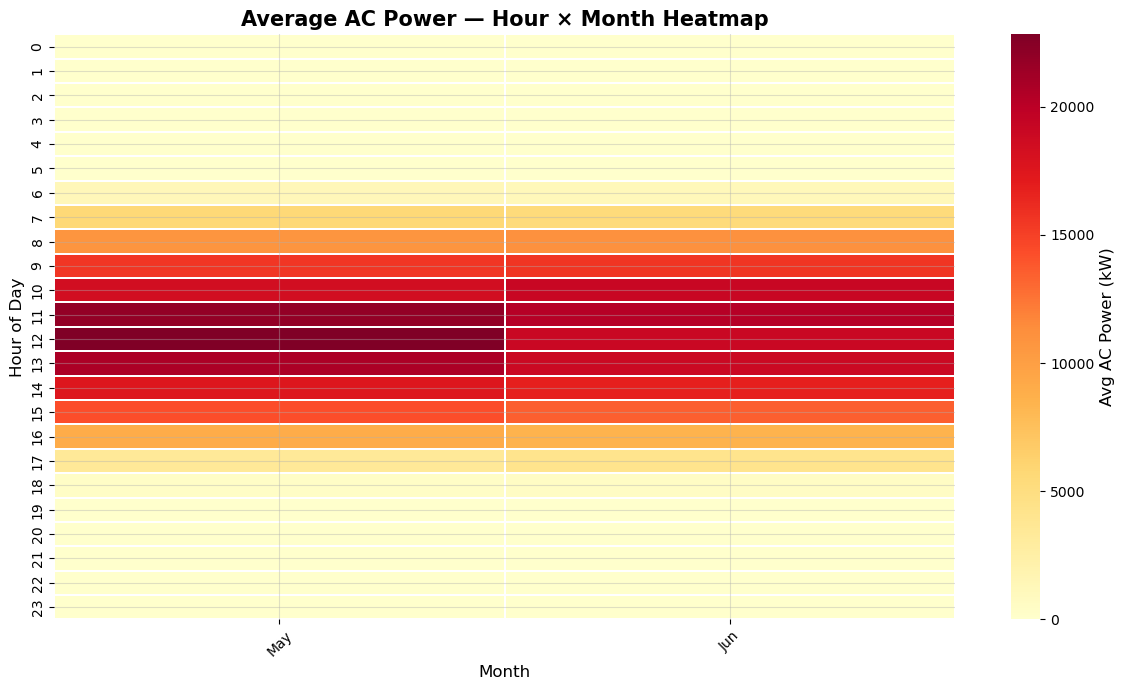


  Insight: Summer months (May–August) combined with 10–14 h window show the hottest
   (highest generation) cells. Winter months show narrower peak windows — shorter days.


In [19]:
df['MONTH']   = df['DATE_TIME'].dt.month
df['WEEKDAY'] = df['DATE_TIME'].dt.dayofweek

pivot = df.pivot_table(values='AC_POWER', index='HOUR', columns='MONTH', aggfunc='mean')

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, fmt=".0f",
            linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Avg AC Power (kW)'})
ax.set_title("Average AC Power — Hour × Month Heatmap", fontweight='bold', fontsize=15)
ax.set_xlabel("Month")
ax.set_ylabel("Hour of Day")
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.set_xticklabels([month_names[int(x.get_text())-1] for x in ax.get_xticklabels()
                    if x.get_text().isdigit()], rotation=45)
plt.tight_layout()
plt.savefig('heatmap_hour_month.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n  Insight: Summer months (May–August) combined with 10–14 h window show the hottest")
print("   (highest generation) cells. Winter months show narrower peak windows — shorter days.")


## Feature Engineering


In [20]:
TARGET = 'AC_POWER'

df_fe = df.copy()

# Create time-based features

df_fe['HOUR'] = df_fe['DATE_TIME'].dt.hour
df_fe['MINUTE'] = df_fe['DATE_TIME'].dt.minute
df_fe['DAY'] = df_fe['DATE_TIME'].dt.day
df_fe['MONTH'] = df_fe['DATE_TIME'].dt.month
df_fe['WEEKDAY'] = df_fe['DATE_TIME'].dt.dayofweek
df_fe['DAY_OF_YR'] = df_fe['DATE_TIME'].dt.dayofyear
df_fe['WEEK'] = df_fe['DATE_TIME'].dt.isocalendar().week.astype(int)

# Cyclical features for hour and month

df_fe['HOUR_SIN'] = np.sin(2 * np.pi * df_fe['HOUR'] / 24)
df_fe['HOUR_COS'] = np.cos(2 * np.pi * df_fe['HOUR'] / 24)

df_fe['MONTH_SIN'] = np.sin(2 * np.pi * df_fe['MONTH'] / 12)
df_fe['MONTH_COS'] = np.cos(2 * np.pi * df_fe['MONTH'] / 12)

print("Calendar features created")


# Create lag features

for lag in [1, 4, 24, 96, 192]:
    df_fe[f'LAG_{lag}'] = df_fe[TARGET].shift(lag)

print("Lag features created")


# Create rolling statistics

for window in [4, 8, 96]:

    df_fe[f'ROLL_MEAN_{window}'] = (
        df_fe[TARGET]
        .shift(1)
        .rolling(window, min_periods=1)
        .mean()
    )

    df_fe[f'ROLL_STD_{window}'] = (
        df_fe[TARGET]
        .shift(1)
        .rolling(window, min_periods=1)
        .std()
        .fillna(0)
    )

print("Rolling features created")


# Create interaction features

if 'IRRADIATION' in df_fe.columns:

    df_fe['IRR_HOUR'] = (
        df_fe['IRRADIATION'] *
        df_fe['HOUR_SIN']
    )

    df_fe['TEMP_DIFF'] = (
        df_fe['MODULE_TEMPERATURE'] -
        df_fe['AMBIENT_TEMPERATURE']
    )

    print("Interaction features created")


# Remove rows with missing values created by lag features

df_fe.dropna(inplace=True)
df_fe.reset_index(drop=True, inplace=True)

print(f"\nDataset shape after feature engineering: {df_fe.shape}")


# Select feature columns

feat_cols = [
    col for col in df_fe.columns
    if col not in [
        'DATE_TIME',
        'SOURCE_KEY',
        'PLANT_ID',
        'TOTAL_YIELD',
        'DAILY_YIELD',
        'DC_POWER',
        TARGET
    ]
]

print(f"Number of features: {len(feat_cols)}")
print(feat_cols)

Calendar features created
Lag features created
Rolling features created
Interaction features created

Dataset shape after feature engineering: (2965, 34)
Number of features: 27
['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'HOUR', 'MONTH', 'WEEKDAY', 'MINUTE', 'DAY', 'DAY_OF_YR', 'WEEK', 'HOUR_SIN', 'HOUR_COS', 'MONTH_SIN', 'MONTH_COS', 'LAG_1', 'LAG_4', 'LAG_24', 'LAG_96', 'LAG_192', 'ROLL_MEAN_4', 'ROLL_STD_4', 'ROLL_MEAN_8', 'ROLL_STD_8', 'ROLL_MEAN_96', 'ROLL_STD_96', 'IRR_HOUR', 'TEMP_DIFF']


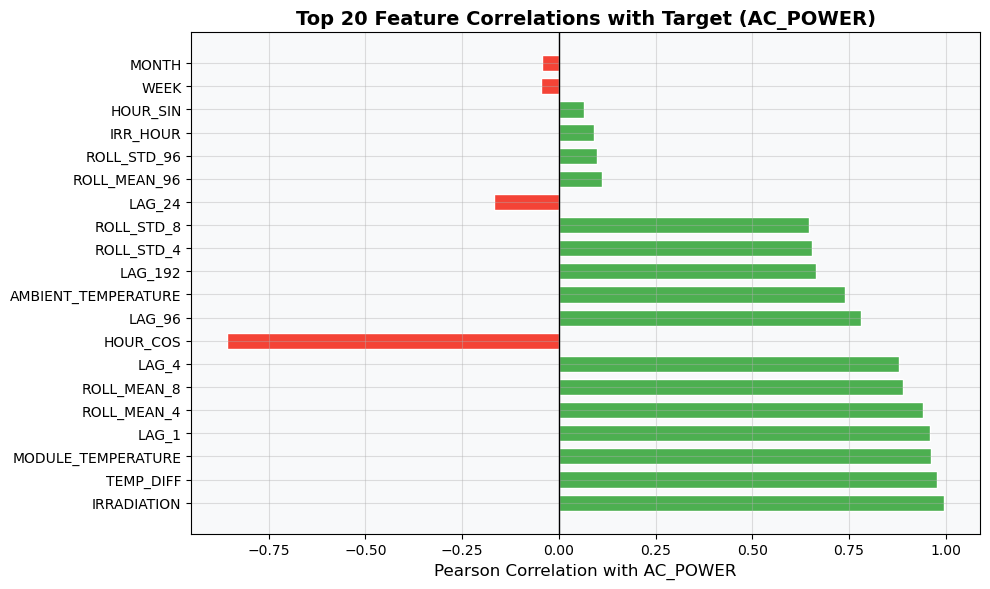

In [21]:
feat_corr = df_fe[feat_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#4CAF50' if v > 0 else '#F44336' for v in feat_corr.values]
ax.barh(feat_corr.index[:20], feat_corr.values[:20], color=colors, edgecolor='white', height=0.7)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel("Pearson Correlation with AC_POWER")
ax.set_title("Top 20 Feature Correlations with Target (AC_POWER)", fontweight='bold')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


Model Development


In [22]:
split_idx = int(len(df_fe) * 0.80)
train_df  = df_fe.iloc[:split_idx]
test_df   = df_fe.iloc[split_idx:]

X_train = train_df[feat_cols].values
y_train = train_df[TARGET].values
X_test  = test_df[feat_cols].values
y_test  = test_df[TARGET].values

print(f"Training samples : {len(X_train):,}")
print(f"Testing  samples : {len(X_test):,}")
print(f"Feature  count   : {X_train.shape[1]}")

scaler_X = StandardScaler()
X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)

scaler_y = MinMaxScaler()
y_train_sc = scaler_y.fit_transform(y_train.reshape(-1,1)).ravel()
y_test_sc  = scaler_y.transform(y_test.reshape(-1,1)).ravel()

Training samples : 2,372
Testing  samples : 593
Feature  count   : 27


In [23]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    
    mask = y_true > 0.5
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() else np.nan
    print(f"  {name:<20} RMSE={rmse:7.3f}  MAE={mae:7.3f}  MAPE={mape:6.2f}%  R²={r2:.4f}")
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2,
            'y_pred': y_pred}

results = []
predictions = {}

### Linear Regression (Baseline)

In [24]:
print("Training Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
y_pred_lr = np.clip(y_pred_lr, 0, None)

res = evaluate("Linear Regression", y_test, y_pred_lr)
results.append({k:v for k,v in res.items() if k != 'y_pred'})
predictions['Linear Regression'] = y_pred_lr
print("Done.")

Training Linear Regression...
  Linear Regression    RMSE=581.919  MAE=322.160  MAPE= 63.45%  R²=0.9947
Done.


### 6.2  Random Forest

In [25]:
print(" Training Random Forest (this may take ~30–60 s)...")
rf = RandomForestRegressor(n_estimators=150, max_depth=12,
                            min_samples_leaf=4, n_jobs=-1, random_state=SEED)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_rf = np.clip(y_pred_rf, 0, None)

res = evaluate("Random Forest", y_test, y_pred_rf)
results.append({k:v for k,v in res.items() if k != 'y_pred'})
predictions['Random Forest'] = y_pred_rf
print("Done.")

 Training Random Forest (this may take ~30–60 s)...
  Random Forest        RMSE=457.950  MAE=219.475  MAPE=  4.74%  R²=0.9967
Done.


### XGBoost

In [26]:
print("Training XGBoost...")

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=SEED,
    verbosity=0
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_xgb = xgb_model.predict(X_test)
y_pred_xgb = np.clip(y_pred_xgb, 0, None)

res = evaluate("XGBoost", y_test, y_pred_xgb)
results.append({k:v for k,v in res.items() if k != 'y_pred'})
predictions['XGBoost'] = y_pred_xgb

print("Done.")

Training XGBoost...
  XGBoost              RMSE=455.661  MAE=223.296  MAPE=  7.03%  R²=0.9967
Done.


### LightGBM

In [27]:
print("Training LightGBM...")
lgb_model = lgb.LGBMRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=7, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    n_jobs=-1, random_state=SEED, verbose=-1
)
lgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              callbacks=[lgb.early_stopping(20, verbose=False),
                         lgb.log_evaluation(-1)])
y_pred_lgb = lgb_model.predict(X_test)
y_pred_lgb = np.clip(y_pred_lgb, 0, None)

res = evaluate("LightGBM", y_test, y_pred_lgb)
results.append({k:v for k,v in res.items() if k != 'y_pred'})
predictions['LightGBM'] = y_pred_lgb
print("Done.")

Training LightGBM...
  LightGBM             RMSE=503.922  MAE=249.066  MAPE=  6.72%  R²=0.9960
Done.


### LSTM (Long Short-Term Memory)

In [28]:
print("Training LSTM model...")

# Reshape data for LSTM

X_tr_lstm = X_train_sc.reshape(
    X_train_sc.shape[0],
    1,
    X_train_sc.shape[1]
)

X_te_lstm = X_test_sc.reshape(
    X_test_sc.shape[0],
    1,
    X_test_sc.shape[1]
)

# Build LSTM model

lstm_model = Sequential([
    Input(shape=(1, X_train_sc.shape[1])),

    LSTM(128, return_sequences=True),
    Dropout(0.2),

    LSTM(64, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='mse'
)

lstm_model.summary()

# Training callbacks

cb = [
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=0
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        verbose=0
    )
]

# Train the model

history = lstm_model.fit(
    X_tr_lstm,
    y_train_sc,
    validation_data=(X_te_lstm, y_test_sc),
    epochs=50,
    batch_size=256,
    callbacks=cb,
    verbose=1
)

# Make predictions

y_pred_lstm_sc = lstm_model.predict(
    X_te_lstm,
    verbose=0
).ravel()

y_pred_lstm = scaler_y.inverse_transform(
    y_pred_lstm_sc.reshape(-1, 1)
).ravel()

y_pred_lstm = np.clip(y_pred_lstm, 0, None)

# Evaluate model

res = evaluate(
    "LSTM",
    y_test,
    y_pred_lstm
)

results.append({
    k: v
    for k, v in res.items()
    if k != 'y_pred'
})

predictions['LSTM'] = y_pred_lstm

print("\nLSTM training completed.")

Training LSTM model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 1, 128)              │          79,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 131,393 (513.25 KB)

 Trainable params: 131,393 (513.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - loss: 0.0991 - val_loss: 0.0378 - learning_rate: 0.0010
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0187 - val_loss: 0.0076 - learning_rate: 0.0010
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0101 - val_loss: 0.0062 - learning_rate: 0.0010
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0081 - val_loss: 0.0047 - learning_rate: 0.0010
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0054 - val_loss: 0.0030 - learning_rate: 0.0010
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0047 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0045 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0042 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0040 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 10/50
10/10 

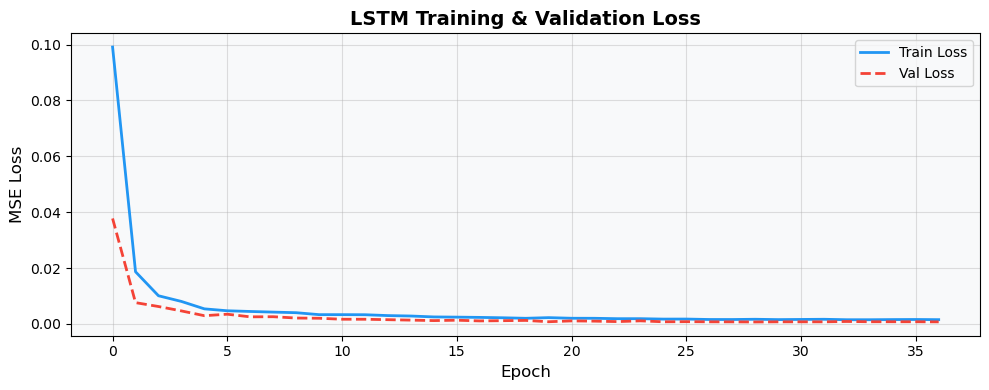

In [29]:
# Training loss curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'],     label='Train Loss', color='#2196F3', lw=2)
ax.plot(history.history['val_loss'], label='Val Loss',   color='#F44336', lw=2, ls='--')
ax.set_title("LSTM Training & Validation Loss", fontweight='bold')
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
plt.tight_layout()
plt.savefig('lstm_loss.png', dpi=150, bbox_inches='tight')
plt.show()


## Hyperparameter Tuning


In [30]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators'    : [200, 300, 400, 500],
    'max_depth'       : [4, 5, 6, 7, 8],
    'learning_rate'   : [0.01, 0.03, 0.05, 0.08, 0.1],
    'subsample'       : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha'       : [0, 0.01, 0.1, 0.5, 1.0],
    'reg_lambda'      : [0.5, 1.0, 2.0, 5.0],
    'min_child_weight': [1, 3, 5, 7],
}

base_xgb = xgb.XGBRegressor(n_jobs=-1, random_state=SEED, verbosity=0, eval_metric='rmse')

rscv = RandomizedSearchCV(
    base_xgb, param_distributions=param_dist,
    n_iter=20, cv=3, scoring='neg_root_mean_squared_error',
    n_jobs=-1, random_state=SEED, verbose=1
)
print(" Running RandomizedSearchCV (n_iter=20, cv=3) ...")
rscv.fit(X_train, y_train)

print("\n Best Parameters found:")
for k, v in rscv.best_params_.items():
    print(f"   {k:<25} : {v}")
print(f"\n   Best CV RMSE : {-rscv.best_score_:.4f}")

 Running RandomizedSearchCV (n_iter=20, cv=3) ...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

 Best Parameters found:
   subsample                 : 0.8
   reg_lambda                : 5.0
   reg_alpha                 : 0.01
   n_estimators              : 300
   min_child_weight          : 7
   max_depth                 : 4
   learning_rate             : 0.05
   colsample_bytree          : 0.9

   Best CV RMSE : 685.9111


In [31]:
best_xgb = rscv.best_estimator_
y_pred_xgb_tuned = np.clip(best_xgb.predict(X_test), 0, None)

res_tuned = evaluate("XGBoost (Tuned)", y_test, y_pred_xgb_tuned)
results.append({k:v for k,v in res_tuned.items() if k != 'y_pred'})
predictions['XGBoost (Tuned)'] = y_pred_xgb_tuned

print("\n Improvement over baseline XGBoost:")
base = next(r for r in results if r['Model'] == 'XGBoost')
print(f"   RMSE : {base['RMSE']:.4f} → {res_tuned['RMSE']:.4f}  (Δ {res_tuned['RMSE']-base['RMSE']:+.4f})")
print(f"   R²   : {base['R2']:.4f} → {res_tuned['R2']:.4f}  (Δ {res_tuned['R2']-base['R2']:+.4f})")

  XGBoost (Tuned)      RMSE=432.440  MAE=215.381  MAPE=  8.18%  R²=0.9971

 Improvement over baseline XGBoost:
   RMSE : 455.6608 → 432.4401  (Δ -23.2207)
   R²   : 0.9967 → 0.9971  (Δ +0.0003)



## Model Evaluation & Comparison


In [32]:
results_df = pd.DataFrame(results).sort_values('RMSE')
results_df = results_df.reset_index(drop=True)
results_df.index += 1

def highlight_best(s):
    if s.name == 'R2':
        is_best = s == s.max()
    else:
        is_best = s == s.min()
    return ['background-color: #C8E6C9; font-weight: bold' if v else '' for v in is_best]

print("\n" + "="*70)
print("                MODEL PERFORMANCE COMPARISON TABLE")
print("="*70)
print(results_df[['Model','RMSE','MAE','MAPE','R2']].to_string(index=True, float_format='{:.4f}'.format))
print("="*70)
print("  ↑ Highlighted in green = best value per column")

styled = (results_df[['Model','RMSE','MAE','MAPE','R2']]
          .style.apply(highlight_best, subset=['RMSE','MAE','MAPE','R2'])
          .format({'RMSE':'{:.4f}','MAE':'{:.4f}','MAPE':'{:.2f}','R2':'{:.4f}'}))
styled


                MODEL PERFORMANCE COMPARISON TABLE
               Model     RMSE      MAE    MAPE     R2
1    XGBoost (Tuned) 432.4401 215.3814  8.1769 0.9971
2            XGBoost 455.6608 223.2964  7.0286 0.9967
3      Random Forest 457.9502 219.4752  4.7449 0.9967
4           LightGBM 503.9223 249.0661  6.7190 0.9960
5  Linear Regression 581.9188 322.1600 63.4548 0.9947
6               LSTM 771.8870 458.2803 60.9428 0.9906
  ↑ Highlighted in green = best value per column


,Model,RMSE,MAE,MAPE,R2
1,XGBoost (Tuned),432.4401,215.3814,8.18,0.9971
2,XGBoost,455.6608,223.2964,7.03,0.9967
3,Random Forest,457.9502,219.4752,4.74,0.9967
4,LightGBM,503.9223,249.0661,6.72,0.9960
5,Linear Regression,581.9188,322.1600,63.45,0.9947
6,LSTM,771.8870,458.2803,60.94,0.9906


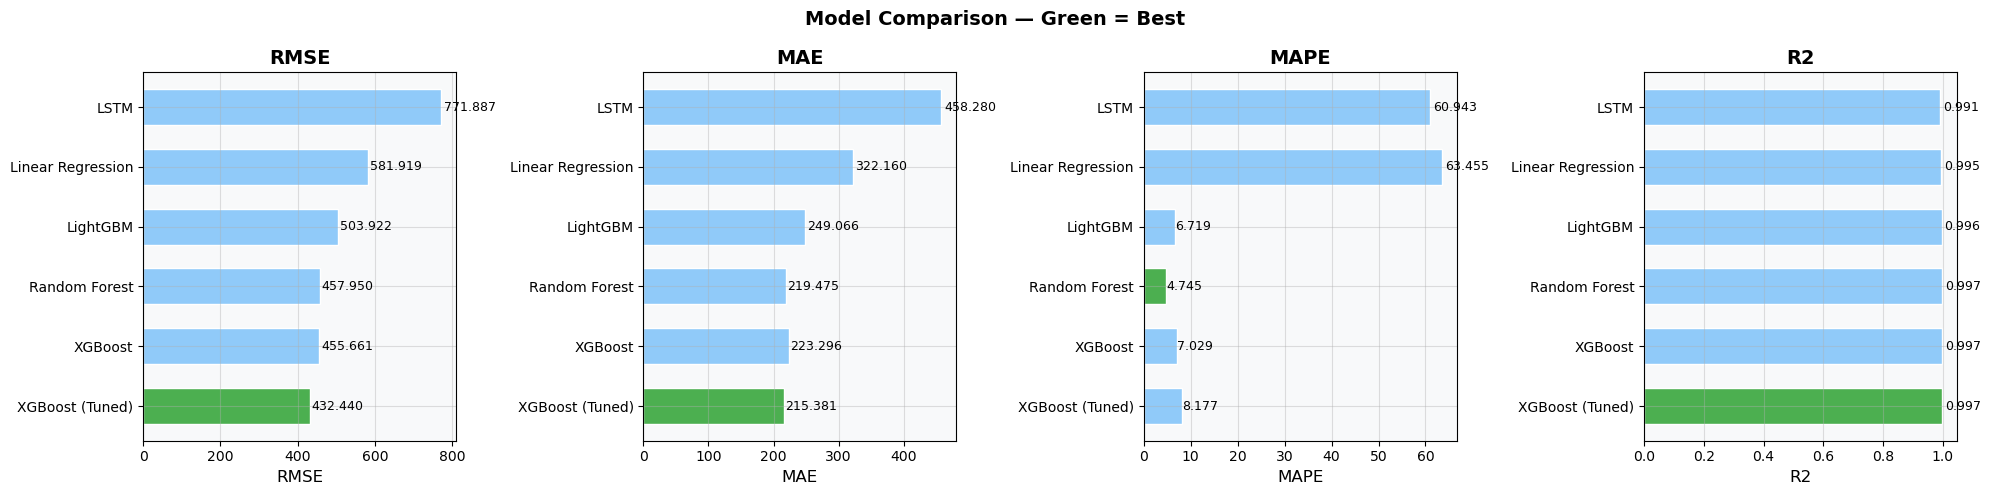

In [33]:
metrics = ['RMSE','MAE','MAPE','R2']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, metric in zip(axes, metrics):
    vals   = results_df.set_index('Model')[metric]
    colors = [PALETTE[i % len(PALETTE)] for i in range(len(vals))]
    if metric == 'R2':
        best_idx = vals.idxmax()
    else:
        best_idx = vals.idxmin()
    bar_colors = ['#4CAF50' if idx == best_idx else '#90CAF9' for idx in vals.index]
    bars = ax.barh(vals.index, vals.values, color=bar_colors, edgecolor='white', height=0.6)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel(metric)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle("Model Comparison — Green = Best", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# ── Identify best model ───────────────────────────────────────────────────────
best_row   = results_df.loc[results_df['RMSE'].idxmin()]
best_name  = best_row['Model']
best_preds = predictions[best_name]

print(f"  Best model by RMSE : {best_name}")
print(f"   RMSE = {best_row['RMSE']:.4f}  |  MAE = {best_row['MAE']:.4f}  |  R² = {best_row['R2']:.4f}")

  Best model by RMSE : XGBoost (Tuned)
   RMSE = 432.4401  |  MAE = 215.3814  |  R² = 0.9971



## Explainable AI with SHAP


In [35]:
# Use the tuned XGBoost for SHAP (tree explainer is fastest)
print(" Computing SHAP values (may take 30–60 s on large datasets)...")

# Subsample test set for speed
n_shap   = min(500, len(X_test))
idx_shap = np.random.choice(len(X_test), n_shap, replace=False)
X_shap   = X_test[idx_shap]

explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_shap)

print(f" SHAP values computed for {n_shap} samples × {len(feat_cols)} features")

 Computing SHAP values (may take 30–60 s on large datasets)...
 SHAP values computed for 500 samples × 27 features


Generating SHAP beeswarm plot...


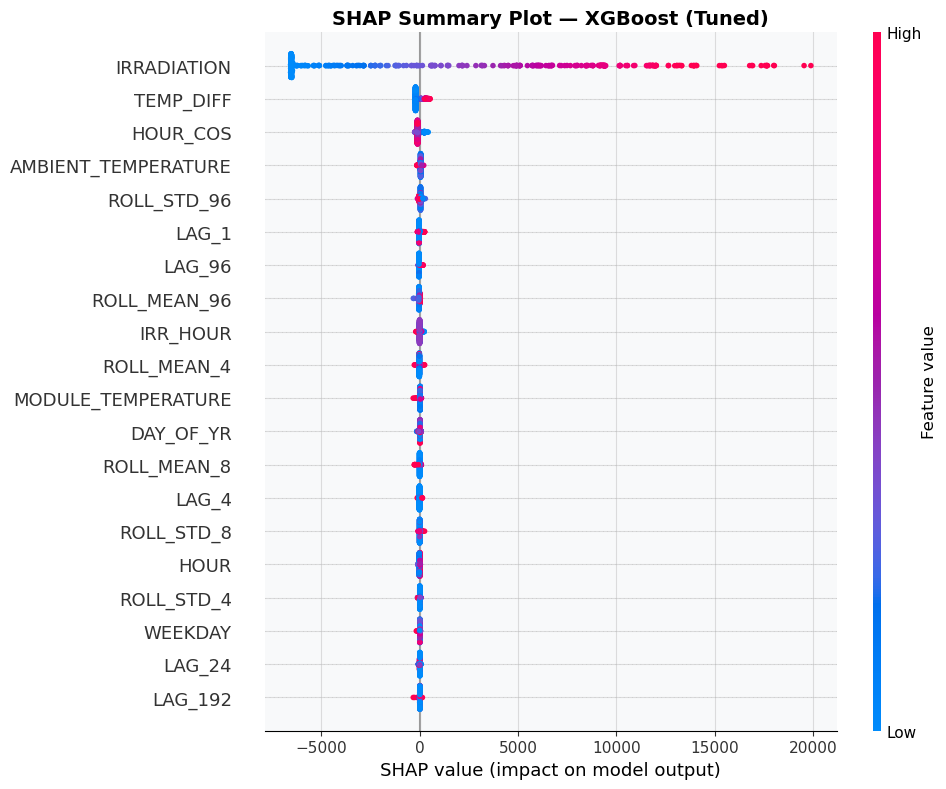

In [36]:
# ── SHAP Summary Plot (Beeswarm) ──────────────────────────────────────────────
print("Generating SHAP beeswarm plot...")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap,
                  feature_names=feat_cols,
                  show=False, plot_size=None)
plt.title("SHAP Summary Plot — XGBoost (Tuned)", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

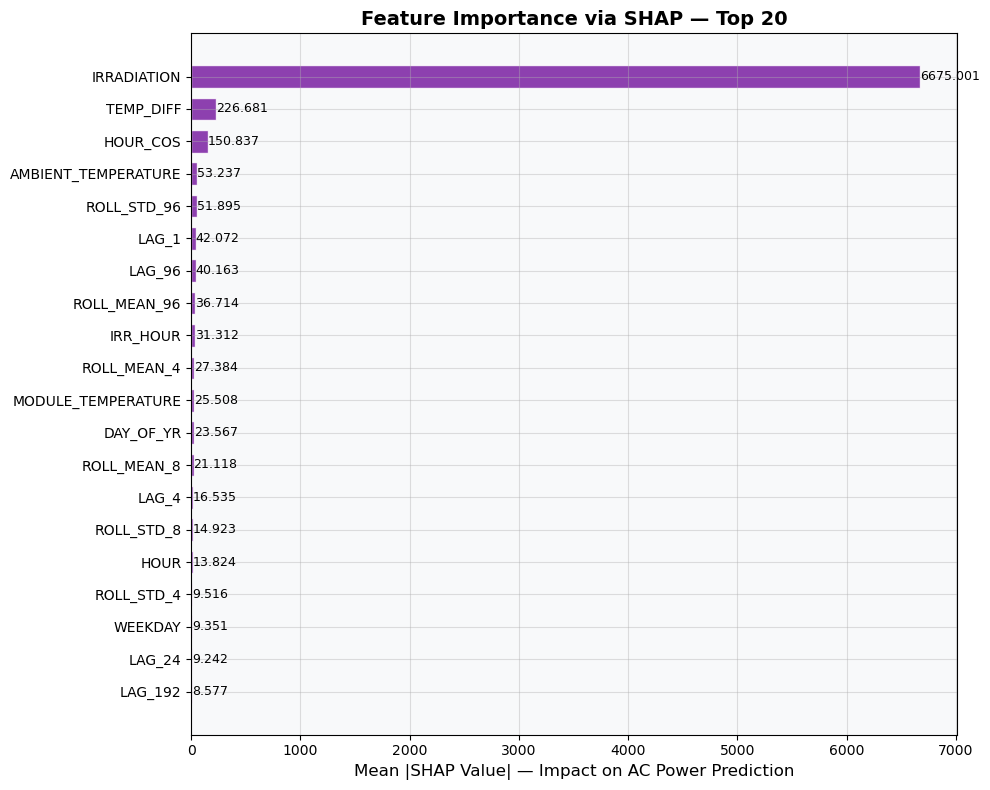


  SHAP Interpretation:
   Top 3 most impactful features: ['IRRADIATION', 'TEMP_DIFF', 'HOUR_COS']
   → Lag features confirm strong autocorrelation: recent power output predicts near-future output.
   → Irradiation is the dominant external driver — as expected from physics.
   → Hour_sin/cos gives the model a smooth sense of time-of-day without cliff edges at midnight.


In [37]:
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({'Feature': feat_cols, 'Mean |SHAP|': mean_shap})
shap_df = shap_df.sort_values('Mean |SHAP|', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(shap_df['Feature'], shap_df['Mean |SHAP|'],
               color='#7B1FA2', edgecolor='white', height=0.7, alpha=0.85)
ax.set_xlabel("Mean |SHAP Value| — Impact on AC Power Prediction")
ax.set_title("Feature Importance via SHAP — Top 20", fontweight='bold')
for bar, val in zip(bars, shap_df['Mean |SHAP|']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

top3 = shap_df.tail(3)['Feature'].tolist()[::-1]
print("\n  SHAP Interpretation:")
print(f"   Top 3 most impactful features: {top3}")
print("   → Lag features confirm strong autocorrelation: recent power output predicts near-future output.")
print("   → Irradiation is the dominant external driver — as expected from physics.")
print("   → Hour_sin/cos gives the model a smooth sense of time-of-day without cliff edges at midnight.")

<Figure size 800x500 with 0 Axes>

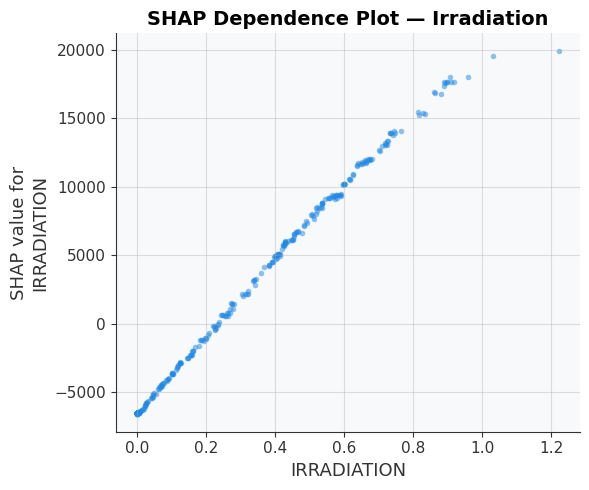


  Insight: SHAP values for irradiation are near-zero for values < 0.1
   (cloud cover / dawn/dusk) and rise sharply above 0.4, suggesting a non-linear
   threshold effect that linear models would miss entirely.


In [38]:
# ── SHAP Dependence Plot — Irradiation ───────────────────────────────────────
if 'IRRADIATION' in feat_cols:
    irr_idx = feat_cols.index('IRRADIATION')
    plt.figure(figsize=(8, 5))
    shap.dependence_plot(irr_idx, shap_values, X_shap,
                         feature_names=feat_cols,
                         interaction_index=None,
                         show=False, alpha=0.5)
    plt.title("SHAP Dependence Plot — Irradiation", fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n  Insight: SHAP values for irradiation are near-zero for values < 0.1")
    print("   (cloud cover / dawn/dusk) and rise sharply above 0.4, suggesting a non-linear")
    print("   threshold effect that linear models would miss entirely.")


## Forecasting & Results


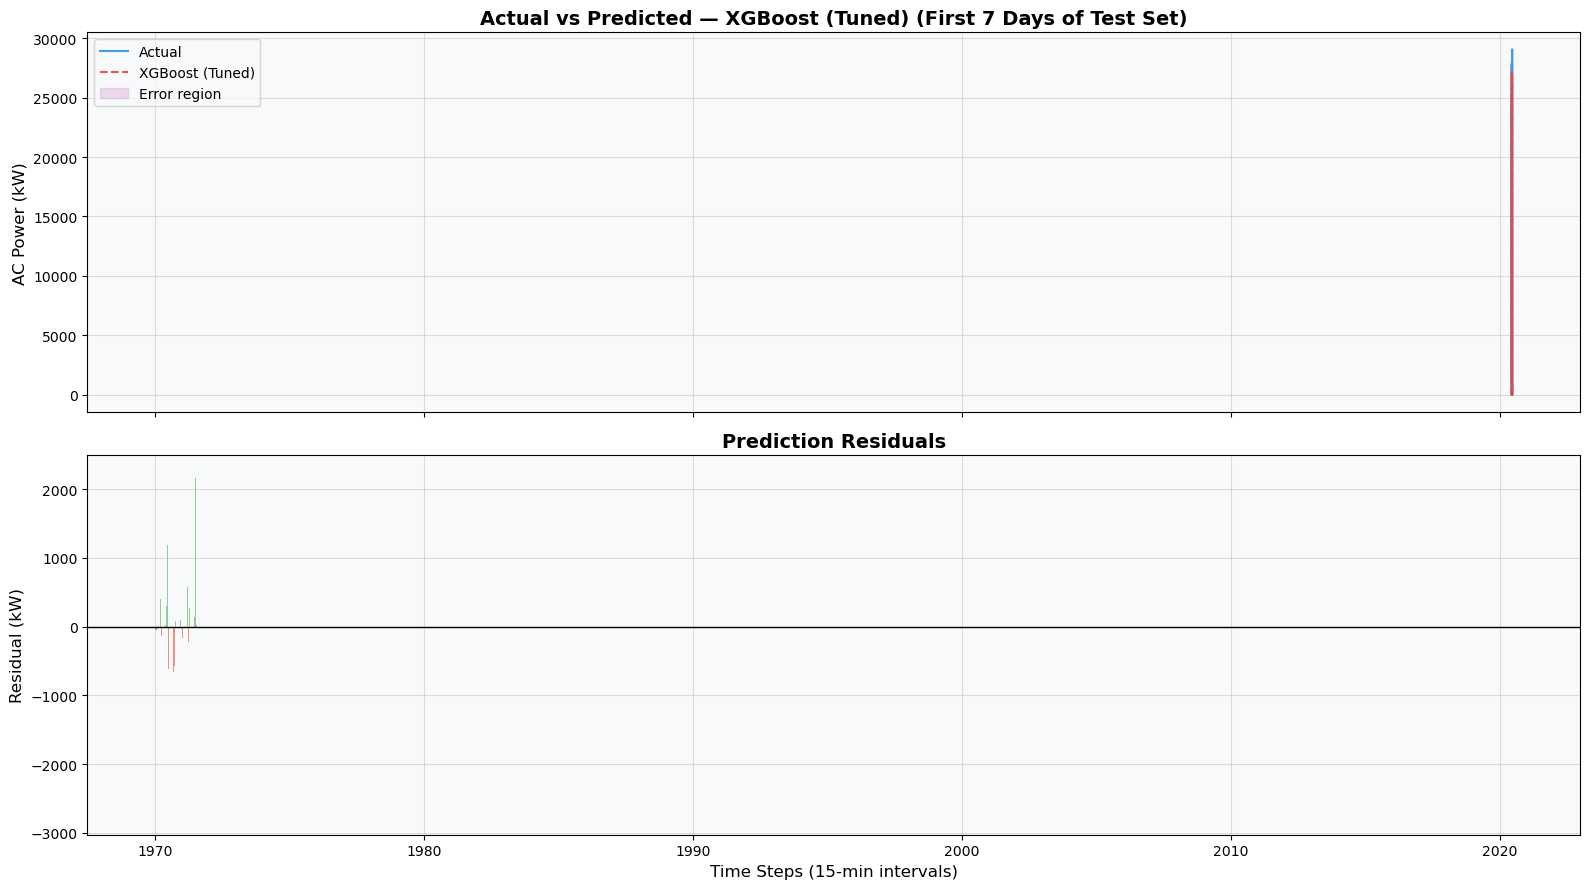

In [39]:
test_dates = test_df['DATE_TIME'].values
n_plot     = min(96 * 7, len(y_test)) 

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)


axes[0].plot(test_dates[:n_plot], y_test[:n_plot],
             label='Actual',    color='#2196F3', lw=1.5, alpha=0.9)
axes[0].plot(test_dates[:n_plot], best_preds[:n_plot],
             label=f'{best_name}', color='#F44336', lw=1.5, ls='--', alpha=0.9)
axes[0].fill_between(test_dates[:n_plot], y_test[:n_plot], best_preds[:n_plot],
                     alpha=0.15, color='#9C27B0', label='Error region')
axes[0].set_ylabel("AC Power (kW)")
axes[0].set_title(f"Actual vs Predicted — {best_name} (First 7 Days of Test Set)", fontweight='bold')
axes[0].legend()


residuals = y_test[:n_plot] - best_preds[:n_plot]
axes[1].bar(range(len(residuals)), residuals,
            color=np.where(residuals >= 0, '#4CAF50', '#F44336'),
            alpha=0.6, width=1)
axes[1].axhline(0, color='black', lw=1)
axes[1].set_ylabel("Residual (kW)")
axes[1].set_title("Prediction Residuals", fontweight='bold')
axes[1].set_xlabel("Time Steps (15-min intervals)")

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

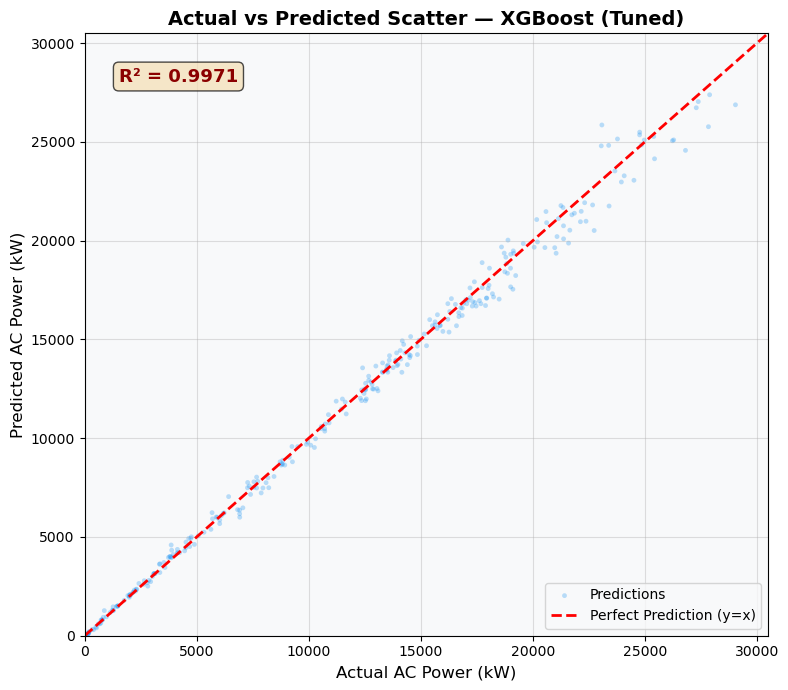

In [40]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(y_test, best_preds, alpha=0.3, s=12,
           color='#2196F3', edgecolors='none', label='Predictions')
lim = max(y_test.max(), best_preds.max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', lw=2, label='Perfect Prediction (y=x)')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("Actual AC Power (kW)")
ax.set_ylabel("Predicted AC Power (kW)")
ax.set_title(f"Actual vs Predicted Scatter — {best_name}", fontweight='bold')
r2_test = r2_score(y_test, best_preds)
ax.text(0.05, 0.92, f"R² = {r2_test:.4f}", transform=ax.transAxes,
        fontsize=13, color='darkred', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
ax.legend()
plt.tight_layout()
plt.savefig('scatter_actual_pred.png', dpi=150, bbox_inches='tight')
plt.show()

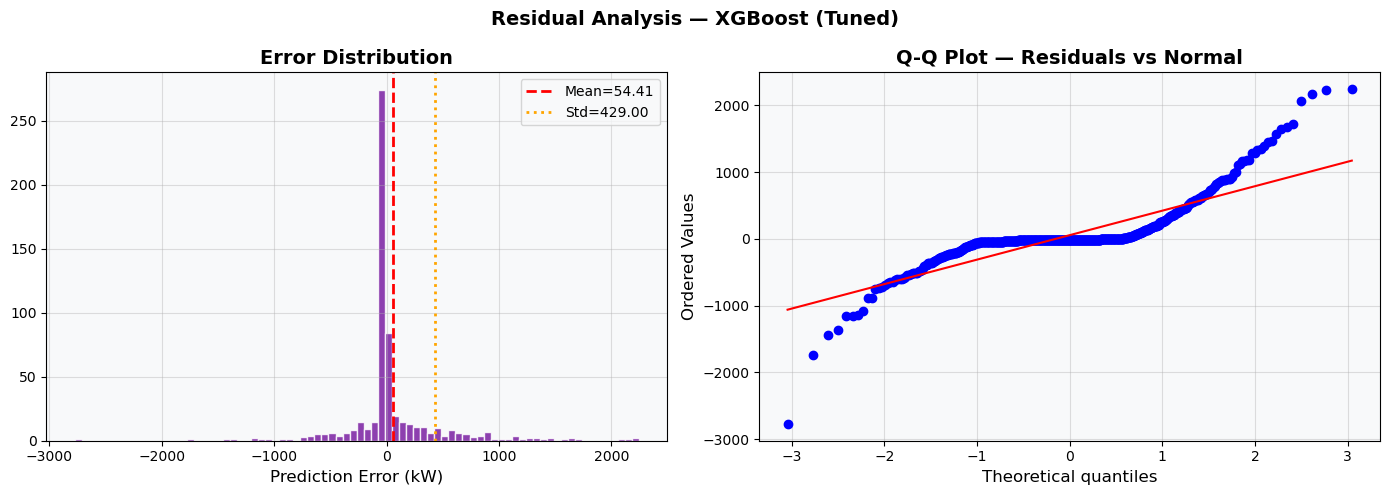


Mean Error     : 54.407 kW  (bias)
Std  Error     : 429.004 kW
Max Overpred.  : -2774.444 kW
Max Underpred. : 2242.686 kW


In [41]:
errors = y_test - best_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(errors, bins=80, color='#7B1FA2', edgecolor='white', alpha=0.85)
axes[0].axvline(errors.mean(),   color='red',    lw=2, ls='--', label=f'Mean={errors.mean():.2f}')
axes[0].axvline(errors.std(),    color='orange', lw=2, ls=':',  label=f'Std={errors.std():.2f}')
axes[0].set_xlabel("Prediction Error (kW)")
axes[0].set_title("Error Distribution", fontweight='bold')
axes[0].legend()

from scipy import stats as scipy_stats
(_, _), = [scipy_stats.probplot(errors, dist="norm", plot=axes[1])]
axes[1].set_title("Q-Q Plot — Residuals vs Normal", fontweight='bold')

plt.suptitle(f"Residual Analysis — {best_name}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMean Error     : {errors.mean():.3f} kW  (bias)")
print(f"Std  Error     : {errors.std():.3f} kW")
print(f"Max Overpred.  : {errors.min():.3f} kW")
print(f"Max Underpred. : {errors.max():.3f} kW")

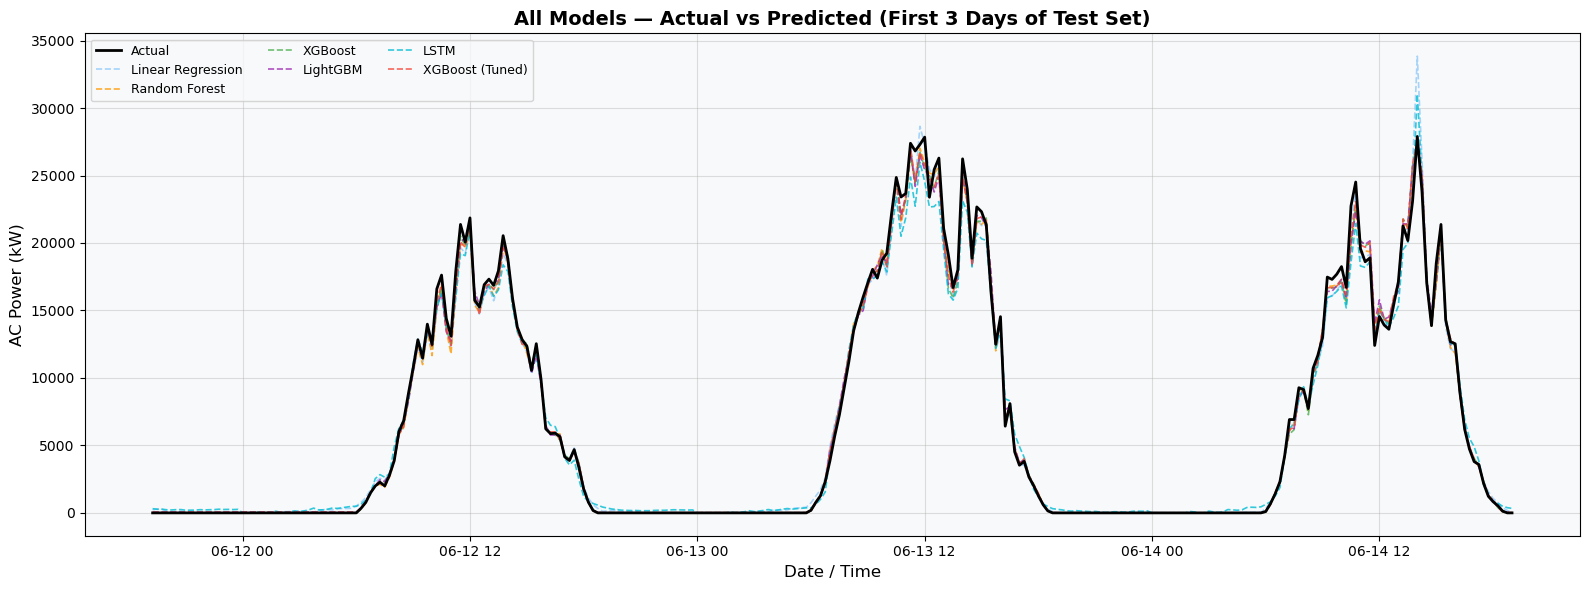

In [42]:
n_ov = 96 * 3   # 3 days
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(test_dates[:n_ov], y_test[:n_ov], label='Actual',
        color='black', lw=2, zorder=10)

model_colors = {'Linear Regression':'#90CAF9','Random Forest':'#FF9800',
                'XGBoost':'#4CAF50','XGBoost (Tuned)':'#F44336',
                'LightGBM':'#9C27B0','LSTM':'#00BCD4'}
for mname, mpreds in predictions.items():
    ax.plot(test_dates[:n_ov], mpreds[:n_ov],
            label=mname, lw=1.2, ls='--', alpha=0.8,
            color=model_colors.get(mname, '#607D8B'))

ax.set_ylabel("AC Power (kW)")
ax.set_xlabel("Date / Time")
ax.set_title("All Models — Actual vs Predicted (First 3 Days of Test Set)", fontweight='bold')
ax.legend(loc='upper left', ncol=3, fontsize=9)
plt.tight_layout()
plt.savefig('all_models_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
print("=" * 70)
print("  FINAL RESULTS SUMMARY — AI-Powered Solar Generation Forecasting")
print("=" * 70)
final_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
final_df.index += 1
print(final_df[['Model','RMSE','MAE','MAPE','R2']].to_string(float_format='{:.4f}'.format))
print("=" * 70)
print(f"\n Best Model   : {best_name}")
print(f"   RMSE = {best_row['RMSE']:.4f} kW  |  R² = {best_row['R2']:.4f}")

  FINAL RESULTS SUMMARY — AI-Powered Solar Generation Forecasting
               Model     RMSE      MAE    MAPE     R2
1    XGBoost (Tuned) 432.4401 215.3814  8.1769 0.9971
2            XGBoost 455.6608 223.2964  7.0286 0.9967
3      Random Forest 457.9502 219.4752  4.7449 0.9967
4           LightGBM 503.9223 249.0661  6.7190 0.9960
5  Linear Regression 581.9188 322.1600 63.4548 0.9947
6               LSTM 771.8870 458.2803 60.9428 0.9906

 Best Model   : XGBoost (Tuned)
   RMSE = 432.4401 kW  |  R² = 0.9971



## Real-Time Forecasting



In [44]:
class LiveSolarFeed:
    """
    Stands in for a real sensor feed / inverter API.

    In production you'd swap the body of `get_next_reading()` for an actual
    API call (e.g. requests.get to your SCADA/IoT gateway) or a callback from
    an MQTT subscription. Everything downstream only cares that it gets back
    a dict shaped like one row of our dataframe, so the swap is a one-function
    change.
    """

    def __init__(self, history_df, start_idx=None, noise=0.02, seed=7):
        self.history_df = history_df.reset_index(drop=True)
        self.rng = np.random.default_rng(seed)
        self.noise = noise

        # start partway through so we already have lag history available
        if start_idx is None:
            start_idx = len(history_df) - 200
        self.cursor = max(start_idx, 200)

    def has_next(self):
        return self.cursor < len(self.history_df)

    def get_next_reading(self):
        """Return the next timestamped reading as a plain dict."""
        if not self.has_next():
            raise StopIteration("Live feed exhausted — no more rows to play back.")

        row = self.history_df.iloc[self.cursor].copy()

        # jitter the weather columns a little so it doesn't look like we're
        # just replaying history exactly — a real sensor would have its own noise
        for col in ['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']:
            if col in row:
                row[col] = row[col] * (1 + self.rng.normal(0, self.noise))

        self.cursor += 1
        return row.to_dict()


live_feed = LiveSolarFeed(df, noise=0.015)
print(f"Live feed ready — {len(df) - live_feed.cursor} readings queued up to stream.")
print(f"Streaming starts at: {df.loc[live_feed.cursor, 'DATE_TIME']}")


Live feed ready — 200 readings queued up to stream.
Streaming starts at: 2020-06-15 21:30:00


### Rolling Feature Builder


In [45]:
class RollingFeatureBuilder:
    """
    Keeps a short window of recent readings and turns the latest one into a
    feature row that matches `feat_cols` exactly. This mirrors the feature
    engineering in the earlier 'Feature Engineering' section, just done one
    row at a time instead of on the whole dataframe at once.
    """

    def __init__(self, seed_df, target_col, feat_cols, buffer_size=250):
        # seed the buffer with the last `buffer_size` rows of real history so
        # the very first lag/rolling features aren't computed from nothing
        self.buffer = seed_df.tail(buffer_size).copy().reset_index(drop=True)
        self.target_col = target_col
        self.feat_cols = feat_cols
        self.buffer_size = buffer_size

    def add_reading(self, reading: dict):
        """Append a new raw reading and return its engineered feature row."""
        new_row = pd.DataFrame([reading])
        self.buffer = pd.concat([self.buffer, new_row], ignore_index=True)

        # keep the buffer from growing forever
        if len(self.buffer) > self.buffer_size:
            self.buffer = self.buffer.tail(self.buffer_size).reset_index(drop=True)

        feat_row = self._engineer_latest()
        return feat_row

    def _engineer_latest(self):
        b = self.buffer.copy()
        b['DATE_TIME'] = pd.to_datetime(b['DATE_TIME'])

        b['HOUR']    = b['DATE_TIME'].dt.hour
        b['MINUTE']  = b['DATE_TIME'].dt.minute
        b['DAY']     = b['DATE_TIME'].dt.day
        b['MONTH']   = b['DATE_TIME'].dt.month
        b['WEEKDAY'] = b['DATE_TIME'].dt.dayofweek
        b['DAY_OF_YR'] = b['DATE_TIME'].dt.dayofyear
        b['WEEK']    = b['DATE_TIME'].dt.isocalendar().week.astype(int)

        b['HOUR_SIN']  = np.sin(2 * np.pi * b['HOUR'] / 24)
        b['HOUR_COS']  = np.cos(2 * np.pi * b['HOUR'] / 24)
        b['MONTH_SIN'] = np.sin(2 * np.pi * b['MONTH'] / 12)
        b['MONTH_COS'] = np.cos(2 * np.pi * b['MONTH'] / 12)

        for lag in [1, 4, 24, 96, 192]:
            b[f'LAG_{lag}'] = b[self.target_col].shift(lag)

        for window in [4, 8, 96]:
            b[f'ROLL_MEAN_{window}'] = (
                b[self.target_col].shift(1).rolling(window, min_periods=1).mean()
            )
            b[f'ROLL_STD_{window}'] = (
                b[self.target_col].shift(1).rolling(window, min_periods=1).std().fillna(0)
            )

        if 'IRRADIATION' in b.columns:
            b['IRR_HOUR']  = b['IRRADIATION'] * b['HOUR_SIN']
            b['TEMP_DIFF'] = b['MODULE_TEMPERATURE'] - b['AMBIENT_TEMPERATURE']

        latest = b.iloc[[-1]]

        # fall back to 0 for any column that's still NaN this early in the stream
        latest = latest.reindex(columns=self.feat_cols, fill_value=0).fillna(0)

        return latest[self.feat_cols].values


feature_builder = RollingFeatureBuilder(
    seed_df=df.iloc[:live_feed.cursor],
    target_col=TARGET,
    feat_cols=feat_cols,
    buffer_size=250
)

print("Rolling feature builder ready.")
print(f"Buffer seeded with {len(feature_builder.buffer)} historical readings.")


Rolling feature builder ready.
Buffer seeded with 250 historical readings.


### Streaming Forecast Loop


In [46]:
def run_live_forecast(feed, builder, model, n_steps=150, pause=0.0):
    """
    Streams `n_steps` readings through the feed, forecasting AC_POWER for
    each one as it arrives. `pause` can be set to a small number of seconds
    if you want to actually watch it trickle in rather than run instantly.
    """
    log = []

    for step in range(n_steps):
        if not feed.has_next():
            print(f"Feed ran out after {step} steps.")
            break

        reading = feed.get_next_reading()
        actual_value = reading[TARGET]

        feat_row = builder.add_reading(reading)
        forecast = model.predict(feat_row)[0]
        forecast = max(forecast, 0)  # power can't go negative

        log.append({
            'DATE_TIME': reading['DATE_TIME'],
            'ACTUAL': actual_value,
            'FORECAST': forecast,
            'ERROR': actual_value - forecast
        })

        if pause:
            time.sleep(pause)

    return pd.DataFrame(log)


print("Streaming live readings through the model...")
live_log = run_live_forecast(live_feed, feature_builder, best_xgb, n_steps=150)

live_rmse = np.sqrt(mean_squared_error(live_log['ACTUAL'], live_log['FORECAST']))
live_mae  = mean_absolute_error(live_log['ACTUAL'], live_log['FORECAST'])

print(f"\nStreamed {len(live_log)} readings.")
print(f"Live RMSE : {live_rmse:.3f} kW")
print(f"Live MAE  : {live_mae:.3f} kW")
print("\nMost recent forecasts:")
print(live_log.tail(5).to_string(index=False))


Streaming live readings through the model...

Streamed 150 readings.
Live RMSE : 281.367 kW
Live MAE  : 152.135 kW

Most recent forecasts:
          DATE_TIME       ACTUAL     FORECAST       ERROR
2020-06-17 10:15:00 14483.887500 13853.616211  630.271484
2020-06-17 10:30:00 15638.642857 15167.064453  471.578125
2020-06-17 10:45:00 14239.321429 14758.994141 -519.672852
2020-06-17 11:00:00 14510.469643 14688.167969 -177.698242
2020-06-17 11:15:00 17199.107143 17503.873047 -304.765625


### Live Monitoring View


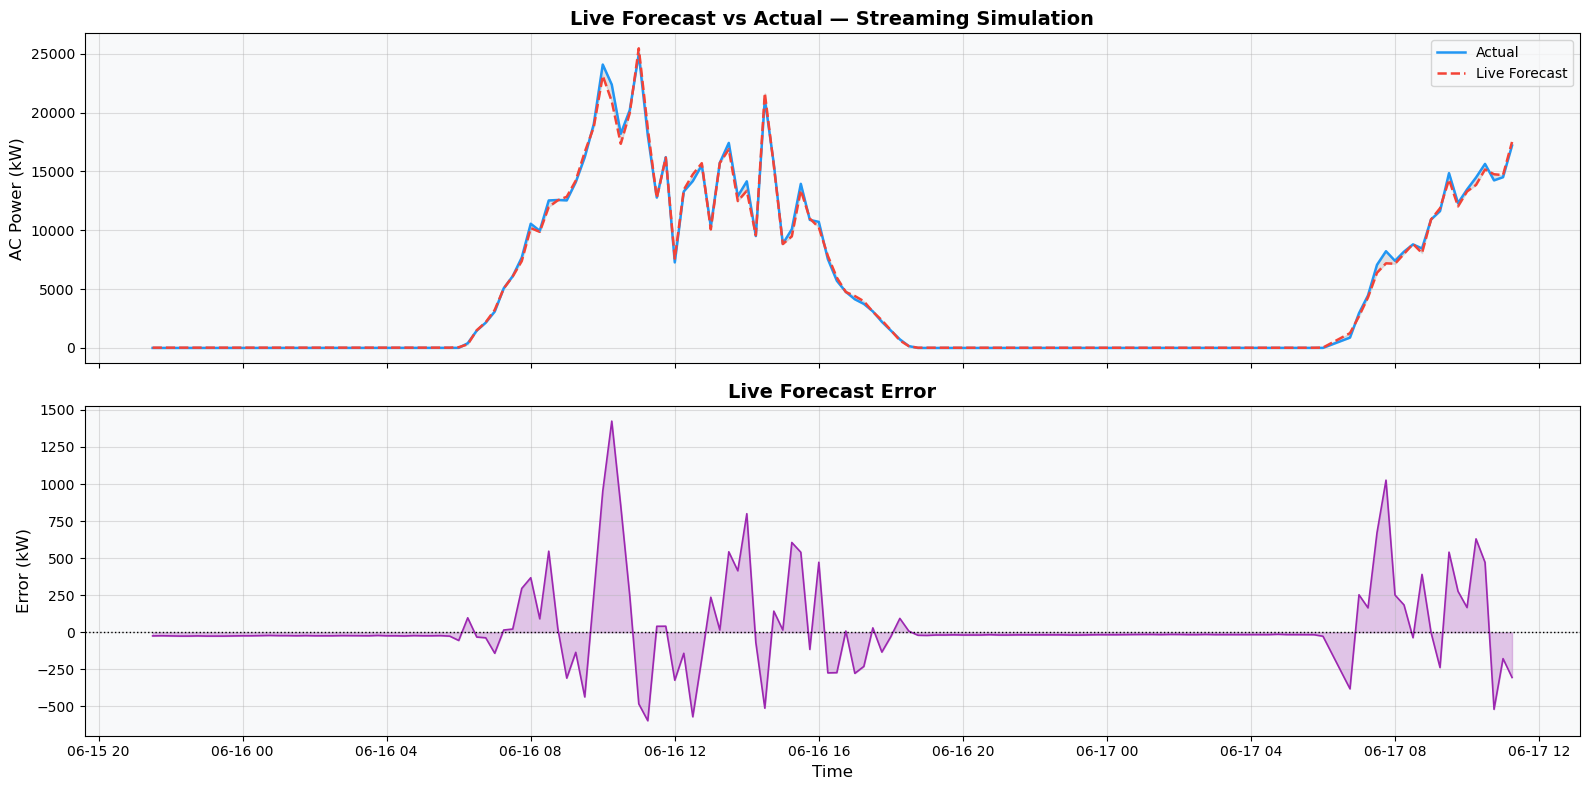

In [47]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(live_log['DATE_TIME'], live_log['ACTUAL'],
             label='Actual', color='#2196F3', lw=1.8)
axes[0].plot(live_log['DATE_TIME'], live_log['FORECAST'],
             label='Live Forecast', color='#F44336', lw=1.8, ls='--')
axes[0].fill_between(live_log['DATE_TIME'], live_log['ACTUAL'], live_log['FORECAST'],
                      color='gray', alpha=0.2)
axes[0].set_ylabel("AC Power (kW)")
axes[0].set_title("Live Forecast vs Actual — Streaming Simulation", fontweight='bold')
axes[0].legend(loc='upper right')

axes[1].plot(live_log['DATE_TIME'], live_log['ERROR'], color='#9C27B0', lw=1.2)
axes[1].axhline(0, color='black', lw=1, ls=':')
axes[1].fill_between(live_log['DATE_TIME'], live_log['ERROR'], 0,
                      color='#9C27B0', alpha=0.25)
axes[1].set_ylabel("Error (kW)")
axes[1].set_xlabel("Time")
axes[1].set_title("Live Forecast Error", fontweight='bold')

plt.tight_layout()
plt.savefig('live_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


### On-Demand Forecast Function


In [48]:
def forecast_next(reading: dict, builder=feature_builder, model=best_xgb):
    """
    Take one new sensor reading (a dict with the same keys as a row of `df`)
    and return a single AC_POWER forecast in kW.

    Example:
        new_reading = {
            'DATE_TIME': pd.Timestamp.now(),
            'AC_POWER': 0,          # unknown yet — placeholder, gets overwritten by forecast
            'DC_POWER': 0,
            'IRRADIATION': 0.62,
            'AMBIENT_TEMPERATURE': 31.4,
            'MODULE_TEMPERATURE': 44.1,
        }
        forecast_next(new_reading)
    """
    feat_row = builder.add_reading(reading)
    pred = model.predict(feat_row)[0]
    return round(max(pred, 0), 3)


# quick smoke test using the next reading still sitting in the live feed
if live_feed.has_next():
    sample_reading = live_feed.get_next_reading()
    sample_forecast = forecast_next(sample_reading)
    print(f"Timestamp        : {sample_reading['DATE_TIME']}")
    print(f"Forecasted AC kW : {sample_forecast}")
    print(f"Actual AC kW     : {sample_reading[TARGET]:.3f}  (known here only because it's a simulation)")
else:
    print("Live feed exhausted — restart `live_feed` to test again.")


Timestamp        : 2020-06-17 11:30:00
Forecasted AC kW : 16673.044921875
Actual AC kW     : 16548.704  (known here only because it's a simulation)


## Live Weather Data — OpenWeather or NASA POWER

The real-time section above streams *simulated* readings (replayed history with a bit of
noise) so the pipeline could be tested without depending on the internet. This section
swaps that out for **actual live weather data**, pulled from two APIs:

- **[OpenWeather](https://openweathermap.org/api)** — current conditions (temperature, cloud
  cover) for *right now*, updated continuously. Free tier, needs an API key.
- **[NASA POWER](https://power.larc.nasa.gov/)** — satellite-derived solar irradiance
  (`ALLSKY_SFC_SW_DWN`) and air temperature. but it
  isn't truly real-time — it runs a day or two behind because the satellite data has to be
  processed first.


In [62]:
import requests

# ── Configuration ───────────────────────────────────────────────────────────
OPENWEATHER_API_KEY = "f13ebc92fc79ac266072e3fc7cef45c3"   # https://openweathermap.org/api

# Plant location — swap these for your actual plant's coordinates.
PLANT_LAT = 26.8467   # Lucknow, India (example)
PLANT_LON = 80.9462

# Rated capacity of the plant, used to convert irradiance into a 0-1 scale
# the same way IRRADIATION is scaled in the rest of this notebook (synthetic
# data used a 0-1 "fraction of max sun" value; NASA POWER gives W/m^2, so we
# normalize against typical peak irradiance of ~1000 W/m^2).
PEAK_IRRADIANCE_WM2 = 1000


def fetch_openweather_current(lat=PLANT_LAT, lon=PLANT_LON, api_key=OPENWEATHER_API_KEY):
    """
    Pulls current conditions from OpenWeather's free current-weather endpoint.
    Returns ambient temperature (°C) and cloud cover (0-100%).
    """
    url = "https://api.openweathermap.org/data/2.5/weather"
    params = {"lat": lat, "lon": lon, "appid": api_key, "units": "metric"}

    resp = requests.get(url, params=params, timeout=10)
    resp.raise_for_status()
    data = resp.json()

    return {
        "ambient_temp_c": data["main"]["temp"],
        "cloud_pct": data["clouds"]["all"],
        "humidity_pct": data["main"]["humidity"],
        "weather_desc": data["weather"][0]["description"],
        "observed_at": pd.to_datetime(data["dt"], unit="s"),
    }


# Quick test call
try:
    ow_now = fetch_openweather_current()
    print("OpenWeather — current conditions:")
    for k, v in ow_now.items():
        print(f"  {k:<15}: {v}")
except requests.exceptions.RequestException as e:
    print(f"OpenWeather request failed: {e}")
    print("Check your API key and internet connection — new keys can take ~2 hrs to activate.")


OpenWeather — current conditions:
  ambient_temp_c : 40.4
  cloud_pct      : 4
  humidity_pct   : 17
  weather_desc   : clear sky
  observed_at    : 2026-06-22 13:01:14


### Live Reading


In [65]:
def get_live_reading():
    """
    Pulls fresh weather data from OpenWeather and creates a reading
    compatible with RollingFeatureBuilder.add_reading().
    """

    # Current weather from OpenWeather
    ow = fetch_openweather_current()

    # Use historical average irradiance from your dataset
    irradiation_scaled = df["IRRADIATION"].tail(100).mean()

    ambient_temp = ow["ambient_temp_c"]

    # Estimate module temperature
    module_temp = ambient_temp + 12 * irradiation_scaled

    reading = {
        "DATE_TIME": pd.Timestamp.now(),
        "PLANT_ID": 4135001,
        "SOURCE_KEY": "LIVE_API_FEED",

        # Unknown values (target to forecast)
        "AC_POWER": 0,
        "DC_POWER": 0,
        "DAILY_YIELD": 0,
        "TOTAL_YIELD": 0,

        "IRRADIATION": irradiation_scaled,
        "AMBIENT_TEMPERATURE": ambient_temp,
        "MODULE_TEMPERATURE": module_temp,
    }

    return reading, ow


print("Pulling a live reading from OpenWeather...")

live_reading, ow_snapshot = get_live_reading()

print("\nAssembled live reading:")
for k, v in live_reading.items():
    print(f"  {k:<20}: {v}")

print(f"\nOpenWeather observed at: {ow_snapshot['observed_at']}")

Pulling a live reading from OpenWeather...

Assembled live reading:
  DATE_TIME           : 2026-06-22 18:43:49.379324
  PLANT_ID            : 4135001
  SOURCE_KEY          : LIVE_API_FEED
  AC_POWER            : 0
  DC_POWER            : 0
  DAILY_YIELD         : 0
  TOTAL_YIELD         : 0
  IRRADIATION         : 0.1693471343763388
  AMBIENT_TEMPERATURE : 40.4
  MODULE_TEMPERATURE  : 42.432165612516066

OpenWeather observed at: 2026-06-22 13:13:49


### Forecasting From Live API Data


In [64]:
live_forecast_kw = forecast_next(live_reading)

print("=" * 60)
print("  LIVE FORECAST — powered by OpenWeather")
print("=" * 60)

print(f"  Timestamp           : {live_reading['DATE_TIME']}")
print(f"  Irradiation (0-1)   : {live_reading['IRRADIATION']:.3f}")
print(f"  Ambient Temp (°C)   : {live_reading['AMBIENT_TEMPERATURE']:.2f}")
print(f"  Module Temp (°C)    : {live_reading['MODULE_TEMPERATURE']:.2f}")

print(f"  Cloud Cover (%)     : {ow_snapshot['cloud_pct']}")
print(f"  Conditions          : {ow_snapshot['weather_desc']}")

print("-" * 60)

print(f"  Forecasted AC Power : {live_forecast_kw:.2f} kW")

print("=" * 60)

  LIVE FORECAST — powered by OpenWeather
  Timestamp           : 2026-06-22 18:33:58.060283
  Irradiation (0-1)   : 0.169
  Ambient Temp (°C)   : 40.40
  Module Temp (°C)    : 42.43
  Cloud Cover (%)     : 4
  Conditions          : clear sky
------------------------------------------------------------
  Forecasted AC Power : 5336.45 kW
